In [107]:
import os
import pandas as pd
from datetime import datetime, timedelta
from efficient_apriori import apriori
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import seaborn as sns

In [121]:
BASE_PATH = os.path.abspath('..\data')

df_raw = pd.read_csv(os.path.join(BASE_PATH, 'raw', 'purchases.csv'))

df_raw['date'] = df_raw['date'].apply(
    lambda x: datetime.strptime(x, '%Y-%m-%d %H:%M:%S')
)

df_raw['month'] = df_raw['date'].apply(lambda x: x.month)
df_raw['year'] = df_raw['date'].apply(lambda x: x.year)

df_raw.head()

,date,company_id,productcategory,quantity,revenue,month,year
0,2020-11-01 13:16:29,4,Gaming,58,2681.31,11,2020
1,2021-06-16 21:03:11,10,Cookware,55,1032.50,6,2021
2,2021-01-20 08:54:45,5,Home Decor,17,1226.12,1,2021
3,2020-08-19 20:57:17,8,Computers,32,1743.84,8,2020
4,2020-07-06 23:55:17,4,Home Improvement,76,851.12,7,2020


### Market Basket Analysis over a sample

In [122]:
# Retrieve transactions

df_transactions = df_raw.sample(n=100, replace=True, random_state=1)


df_transactions = df_transactions.groupby(
    ['year', 'month'],
    as_index = False
).agg(
    {
        'productcategory': 'unique',
        'quantity':'sum'
    }
)


df_transactions['productcategory'] = df_transactions['productcategory'].apply(
    lambda x: tuple(x)
)

transactions = list(
    df_transactions['productcategory']
)

transactions

[('Computers',
  'Home Decor',
  'Sports & Outdoors',
  'Cameras',
  'Pet Supplies',
  'Home & Kitchen',
  'Security & Surveillance'),
 ('Clothing', 'Office Supplies', 'Appliances'),
 ('Gaming',),
 ('Gaming', 'Computers', 'Outdoor', 'Smart Accessories', 'Wearable Tech'),
 ('Toys & Games',
  'Security & Surveillance',
  'Smart Accessories',
  'Cameras',
  'Cookware',
  'Mobile Devices'),
 ('Home Decor',
  'Home & Kitchen',
  'Wearable Tech',
  'Books & E-readers',
  'Automotive',
  'Clothing'),
 ('Clothing', 'Computers', 'Home Decor'),
 ('Audio', 'Gaming', 'Office Supplies'),
 ('Cameras', 'Electronics'),
 ('Electronics', 'Appliances', 'Footwear', 'Pet Supplies'),
 ('Sports & Outdoors',
  'Mobile Devices',
  'Home & Kitchen',
  'Footwear',
  'Smart Home',
  'Outdoor',
  'Smart Accessories',
  'Pet Supplies'),
 ('Footwear',
  'Home Improvement',
  'Pet Supplies',
  'Audio',
  'Mobile Devices',
  'Sports & Outdoors',
  'Smart Accessories'),
 ('Footwear', 'Smart Home', 'Mobile Devices', 'Fi

In [138]:
itemsets, rules = apriori(transactions, min_support=0.1,  min_confidence=0.8)
# Print out every rule with 2 items on the left hand side,
# 1 item on the right hand side, sorted by lift
rules_rhs = filter(lambda rule: len(rule.lhs) == 2 and len(rule.rhs) == 1, rules)
for rule in sorted(rules_rhs, key=lambda rule: rule.lift):
  print(rule) # Prints the rule and its confidence, support, lift, ...

{Fitness & Health, Office Supplies} -> {Audio} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Gaming, Office Supplies} -> {Audio} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Home Decor, Security & Surveillance} -> {Computers} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Computers, Security & Surveillance} -> {Home Decor} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Footwear, Smart Accessories} -> {Mobile Devices} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Mobile Devices, Smart Home} -> {Footwear} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Footwear, Smart Home} -> {Mobile Devices} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Mobile Devices, Sports & Outdoors} -> {Footwear} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Footwear, Sports & Outdoors} -> {Mobile Devices} (conf: 1.000, supp: 0.111, lift: 3.600, conv: 722222222.222)
{Footwear, Smart Accessor

### Dimensionality Reduction

In [42]:
BASE_PATH = os.path.abspath('..\data')

df_gold = pd.read_csv(os.path.join(BASE_PATH, 'gold', 'purchases.csv'))
df_gold['date'] = df_gold['date'].apply(
    lambda x: datetime.strptime(str(x), '%Y-%m-%d')
)
df_gold.head()

,date,month,productcategory,company_type,company_employees,previous_sales,cpi,unemployment_rate,sales
0,2020-02-01,2,Appliances,non-profit,1-10,889.0,257.971,3.5,610.0
1,2020-02-01,2,Appliances,non-profit,101-500,648.0,257.971,3.5,1544.0
2,2020-02-01,2,Appliances,private,1-10,1862.0,257.971,3.5,2535.0
3,2020-02-01,2,Appliances,private,"500-1,000",785.0,257.971,3.5,923.0
4,2020-02-01,2,Appliances,private,51-100,3171.0,257.971,3.5,3704.0


In [81]:
X = df_gold.drop(
    ['date', 'sales'],
    axis=1
)


In [82]:
## Code features
t = ColumnTransformer(
    transformers=[(
        'onehot',  
        OneHotEncoder(handle_unknown='ignore'), 
        [
            'productcategory',
            'company_type',
            'company_employees',
            'month'
        ]
    ),
    (
        'scale',
        StandardScaler(),
        [
            'previous_sales',
            'unemployment_rate',
            'cpi'
        ]
    )],
    remainder='passthrough'
)


X_scaled= t.fit_transform(X)

X_scaled = X_scaled.toarray()

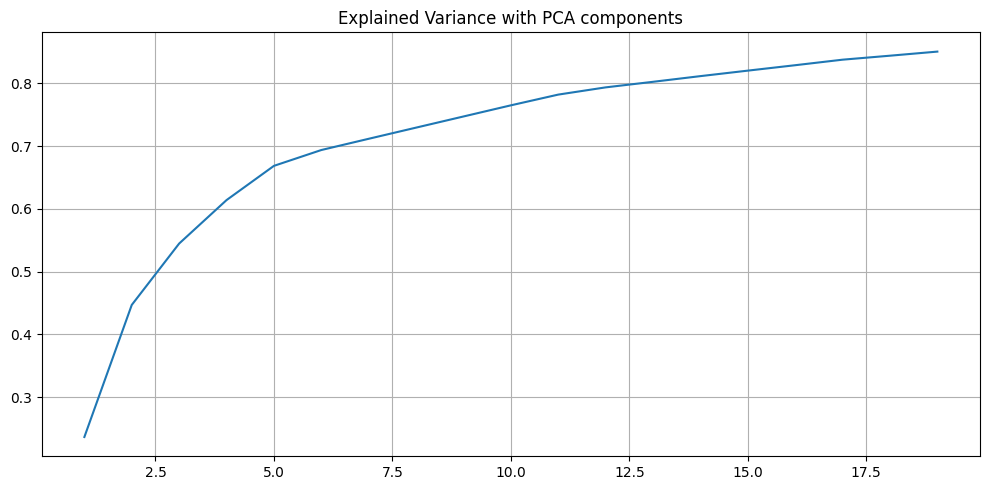

In [60]:
# Best PCA components

explained_variance = []
max_components = 20
for comp in range(1, max_components):
    pca = PCA(n_components=comp)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))


plt.figure(figsize=(10, 5))
plt.plot(range(1, max_components), explained_variance)
plt.title('Explained Variance with PCA components')
plt.grid()
plt.tight_layout()
plt.show()


In [67]:
pca = PCA(n_components=12)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=[f'component {i}' for i in range(12)])
df_pca.head()

,component 0,component 1,component 2,component 3,component 4,component 5,component 6,component 7,component 8,component 9,component 10,component 11
0,-0.509331,-0.784746,1.425597,0.962843,-0.597575,-0.199692,0.501384,-0.340138,-0.093113,-0.243728,0.561602,-0.174264
1,-0.552560,-1.243309,1.412214,0.709439,0.365401,0.652576,0.632579,-0.339609,-0.091437,-0.244836,0.223351,-0.171173
2,-0.367967,0.662440,1.450757,0.268495,-0.637960,-0.322996,0.857940,-0.338296,-0.088859,-0.246040,-0.169165,-0.171020
3,-0.492637,-0.567328,1.440963,-0.756151,-0.811128,0.624093,0.697486,-0.339077,-0.090849,-0.245328,0.068757,-0.168726
4,-0.214666,2.174824,1.462461,-0.108293,0.391199,0.221231,0.562270,-0.339764,-0.092455,-0.243805,0.486423,-0.176910


### ***Exercise***: Try make a dimensionality Reduction using Singular Valud Decomposition (SVD)

### Clustering

Hierarchical clustering

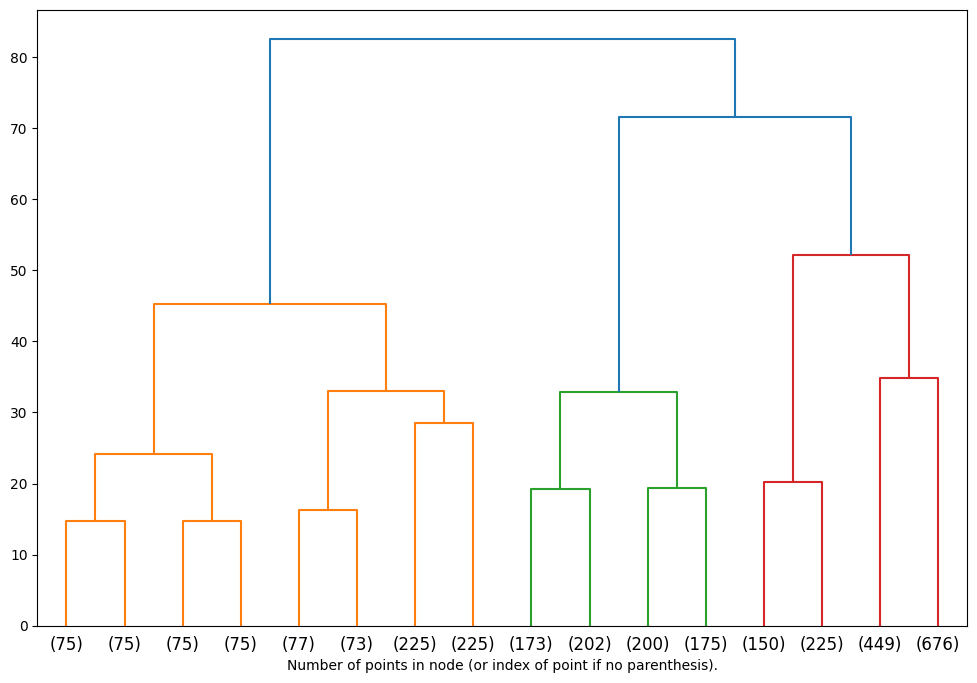

In [94]:
# Agglomerative clustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# setting distance_threshold=0 ensures we compute the full tree.

model = AgglomerativeClustering(distance_threshold=55, n_clusters=None)
model = model.fit(X_scaled)
plt.figure(figsize=(12, 8))
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

In [96]:
print(set(model.labels_))

df_clust = df_gold.copy()
df_clust['cluster'] = model.labels_
df_clust.head()

{0, 1, 2}


,date,month,productcategory,company_type,company_employees,previous_sales,cpi,unemployment_rate,sales,cluster
0,2020-02-01,2,Appliances,non-profit,1-10,889.0,257.971,3.5,610.0,0
1,2020-02-01,2,Appliances,non-profit,101-500,648.0,257.971,3.5,1544.0,0
2,2020-02-01,2,Appliances,private,1-10,1862.0,257.971,3.5,2535.0,1
3,2020-02-01,2,Appliances,private,"500-1,000",785.0,257.971,3.5,923.0,0
4,2020-02-01,2,Appliances,private,51-100,3171.0,257.971,3.5,3704.0,1


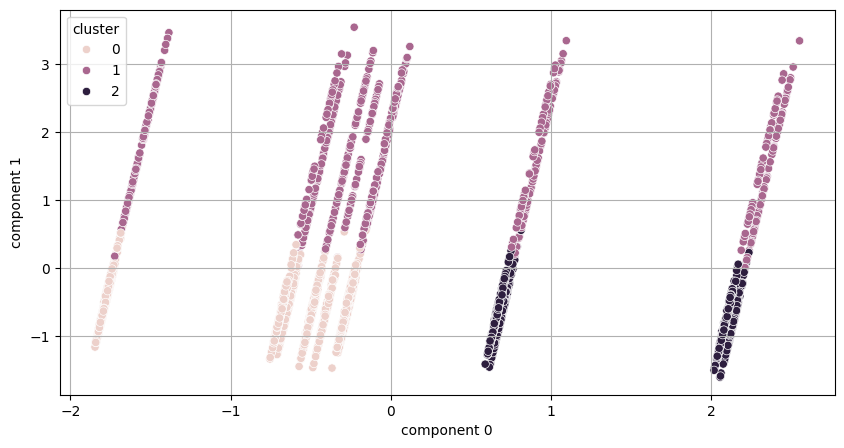

In [109]:
## We can apply dimensionality Reduction to visualize clusters

df_pca_clust = df_pca.copy()

df_pca_clust['cluster'] = model.labels_
df_pca_clust.head()

fig = plt.figure(figsize=(10, 5))
sns.scatterplot(
    data = df_pca_clust,
    x = 'component 0',
    y = 'component 1',
    hue='cluster'
)
plt.grid()

### ***Exercise***: Try cluster data using K-means with Elbow locator